# Attention U-Net — Brain MRI Tumor Segmentation
**COMPSCI 9553/4452 – Deep Learning in Computer Vision**

Model: Attention U-Net (from scratch)
Dataset: LGG MRI Segmentation (preprocessed, augmented)
Input: 128x128 grayscale (1-channel)
Task: Binary segmentation (tumor vs. background)

## 1. Mount Google Drive and Extract Dataset

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import zipfile, os, shutil

ZIP_PATH    = '/content/drive/MyDrive/2_processed_dataset_with_data_augmentation.zip'
EXTRACT_BASE = '/content/dataset'
EXTRACT_DIR  = '/content/dataset/2_processed_dataset_with_data_augmentation'

if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset...')
    if os.path.exists(EXTRACT_BASE):
        shutil.rmtree(EXTRACT_BASE)
    os.makedirs(EXTRACT_BASE)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_BASE)
    print('Done.')
else:
    print('Already extracted.')


Already extracted.


In [20]:
for root, dirs, files in os.walk(EXTRACT_DIR):
    depth = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    if depth >= 2:
        print(f'{indent}  ... ({len(files)} files)')
        dirs[:] = []

2_processed_dataset_with_data_augmentation/
  test/
    masks/
      ... (565 files)
    images/
      ... (565 files)
  validation/
    masks/
      ... (672 files)
    images/
      ... (672 files)
  train/
    masks/
      ... (3580 files)
    images/
      ... (3580 files)


## 2. Imports and Config

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from glob import glob
import random
from scipy.ndimage import distance_transform_edt
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

IMG_SIZE    = 128
IN_CHANNELS = 1
BATCH_SIZE  = 16
LR          = 1e-4
MAX_EPOCHS  = 100
PATIENCE    = 10
NUM_WORKERS = 2

Using device: cuda


## 3. Dataset

In [22]:
class MRIDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_paths  = sorted(glob(os.path.join(img_dir,  '*.tif')))
        self.mask_paths = sorted(glob(os.path.join(mask_dir, '*.tif')))
        assert len(self.img_paths) == len(self.mask_paths)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = np.array(Image.open(self.img_paths[idx]).convert('L'),  dtype=np.float32) / 255.0
        mask = np.array(Image.open(self.mask_paths[idx]).convert('L'), dtype=np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)
        img  = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        return img, mask


# Update these if your folder structure is different
TRAIN_IMG_DIR  = os.path.join(EXTRACT_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(EXTRACT_DIR, 'train', 'masks')
VAL_IMG_DIR    = os.path.join(EXTRACT_DIR, 'validation', 'images')
VAL_MASK_DIR   = os.path.join(EXTRACT_DIR, 'validation', 'masks')
TEST_IMG_DIR   = os.path.join(EXTRACT_DIR, 'test',  'images')
TEST_MASK_DIR  = os.path.join(EXTRACT_DIR, 'test',  'masks')

train_ds = MRIDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
val_ds   = MRIDataset(VAL_IMG_DIR,   VAL_MASK_DIR)
test_ds  = MRIDataset(TEST_IMG_DIR,  TEST_MASK_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 3580 | Val: 672 | Test: 565


## 4. Attention U-Net Architecture

In [23]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1, bias=False),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape != x1.shape:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.enc1 = DoubleConv(in_channels,  features[0])
        self.enc2 = DoubleConv(features[0],  features[1])
        self.enc3 = DoubleConv(features[1],  features[2])
        self.enc4 = DoubleConv(features[2],  features[3])
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(features[3], features[3] * 2)
        self.up4 = nn.ConvTranspose2d(features[3]*2, features[3], 2, stride=2)
        self.up3 = nn.ConvTranspose2d(features[3],   features[2], 2, stride=2)
        self.up2 = nn.ConvTranspose2d(features[2],   features[1], 2, stride=2)
        self.up1 = nn.ConvTranspose2d(features[1],   features[0], 2, stride=2)
        self.att4 = AttentionGate(F_g=features[3], F_l=features[3], F_int=features[2])
        self.att3 = AttentionGate(F_g=features[2], F_l=features[2], F_int=features[1])
        self.att2 = AttentionGate(F_g=features[1], F_l=features[1], F_int=features[0])
        self.att1 = AttentionGate(F_g=features[0], F_l=features[0], F_int=features[0]//2)
        self.dec4 = DoubleConv(features[3]*2, features[3])
        self.dec3 = DoubleConv(features[2]*2, features[2])
        self.dec2 = DoubleConv(features[1]*2, features[1])
        self.dec1 = DoubleConv(features[0]*2, features[0])
        self.out_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        b  = self.bottleneck(self.pool(s4))
        d4 = self.up4(b)
        s4 = self.att4(g=d4, x=s4)
        d4 = self.dec4(torch.cat([d4, s4], dim=1))
        d3 = self.up3(d4)
        s3 = self.att3(g=d3, x=s3)
        d3 = self.dec3(torch.cat([d3, s3], dim=1))
        d2 = self.up2(d3)
        s2 = self.att2(g=d2, x=s2)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))
        d1 = self.up1(d2)
        s1 = self.att1(g=d1, x=s1)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))
        return self.out_conv(d1)


model = AttentionUNet(in_channels=IN_CHANNELS).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Attention U-Net | Trainable parameters: {total_params:,}')

Attention U-Net | Trainable parameters: 31,387,049


## 5. Loss Function

In [24]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce_w  = bce_weight
        self.dice_w = dice_weight
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def dice_loss(self, logits, targets):
        probs   = torch.sigmoid(logits).view(-1)
        targets = targets.view(-1)
        inter   = (probs * targets).sum()
        return 1 - (2. * inter + self.smooth) / (probs.sum() + targets.sum() + self.smooth)

    def forward(self, logits, targets):
        return self.bce_w * self.bce(logits, targets) + self.dice_w * self.dice_loss(logits, targets)


criterion = BCEDiceLoss()

## 6. Evaluation Metrics

In [25]:
def compute_metrics(preds, targets, threshold=0.5, smooth=1e-6):
    probs  = torch.sigmoid(preds)
    binary = (probs > threshold).float()
    b = binary.view(-1).cpu().numpy()
    t = targets.view(-1).cpu().numpy()

    accuracy = (b == t).mean()
    inter = (b * t).sum()
    dice  = (2. * inter + smooth) / (b.sum() + t.sum() + smooth)
    union = b.sum() + t.sum() - inter
    iou   = (inter + smooth) / (union + smooth)

    hd_list = []
    for i in range(binary.shape[0]):
        pred_np = binary[i, 0].cpu().numpy().astype(bool)
        tgt_np  = targets[i, 0].cpu().numpy().astype(bool)
        if pred_np.any() and tgt_np.any():
            d1 = distance_transform_edt(~tgt_np)[pred_np].max()
            d2 = distance_transform_edt(~pred_np)[tgt_np].max()
            hd_list.append(max(d1, d2))
        elif pred_np.any() or tgt_np.any():
            hd_list.append(float(IMG_SIZE))

    return {'accuracy': float(accuracy), 'dice': float(dice),
            'iou': float(iou), 'hausdorff': float(np.mean(hd_list)) if hd_list else 0.0}

## 7. Training Loop with Early Stopping

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': [], 'val_acc': [], 'val_hd': []}
best_val_loss    = float('inf')
patience_counter = 0
CKPT_PATH        = '/content/best_attention_unet.pth'

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch}/{MAX_EPOCHS}', leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss = 0.0
    all_preds, all_masks_list = [], []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            val_loss += criterion(logits, masks).item() * imgs.size(0)
            all_preds.append(logits.cpu())
            all_masks_list.append(masks.cpu())
    val_loss /= len(val_ds)

    metrics = compute_metrics(torch.cat(all_preds), torch.cat(all_masks_list))

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(metrics['dice'])
    history['val_iou'].append(metrics['iou'])
    history['val_acc'].append(metrics['accuracy'])
    history['val_hd'].append(metrics['hausdorff'])

    scheduler.step(val_loss)
    print(f'Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | '
          f'Dice: {metrics["dice"]:.4f} | IoU: {metrics["iou"]:.4f} | '
          f'Acc: {metrics["accuracy"]:.4f} | HD: {metrics["hausdorff"]:.2f}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  --> Best model saved (val_loss={best_val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

print('Training complete.')

Epoch   1 | Train: 0.6504 | Val: 0.6079 | Dice: 0.3375 | IoU: 0.2030 | Acc: 0.9857 | HD: 83.94
  --> Best model saved (val_loss=0.6079)


Epoch   2 | Train: 0.5844 | Val: 0.5590 | Dice: 0.4166 | IoU: 0.2631 | Acc: 0.9853 | HD: 74.60
  --> Best model saved (val_loss=0.5590)


Epoch   3 | Train: 0.5419 | Val: 0.5302 | Dice: 0.4128 | IoU: 0.2601 | Acc: 0.9856 | HD: 71.25
  --> Best model saved (val_loss=0.5302)


Epoch   4 | Train: 0.5066 | Val: 0.4935 | Dice: 0.4361 | IoU: 0.2788 | Acc: 0.9778 | HD: 80.68
  --> Best model saved (val_loss=0.4935)


Epoch   5 | Train: 0.4743 | Val: 0.4718 | Dice: 0.4454 | IoU: 0.2865 | Acc: 0.9806 | HD: 77.70
  --> Best model saved (val_loss=0.4718)


...

Epoch  26 | Train: 0.2422 | Val: 0.3600 | Dice: 0.5710 | IoU: 0.3995 | Acc: 0.9903 | HD: 62.81


Epoch  27 | Train: 0.2334 | Val: 0.3663 | Dice: 0.5537 | IoU: 0.3828 | Acc: 0.9902 | HD: 63.73


Epoch  28 | Train: 0.2273 | Val: 0.3559 | Dice: 0.5778 | IoU: 0.4062 | Acc: 0.9901 | HD: 61.01


Epoch  29 | Train: 0.2198 | Val: 0.3526 | Dice: 0.5846 | IoU: 0.4130 | Acc: 0.9905 | HD: 59.13


Epoch  30 | Train: 0.2246 | Val: 0.3707 | Dice: 0.5531 | IoU: 0.3823 | Acc: 0.9898 | HD: 65.81
Early stopping at epoch 30.
Training complete.


## 8. Training Curves

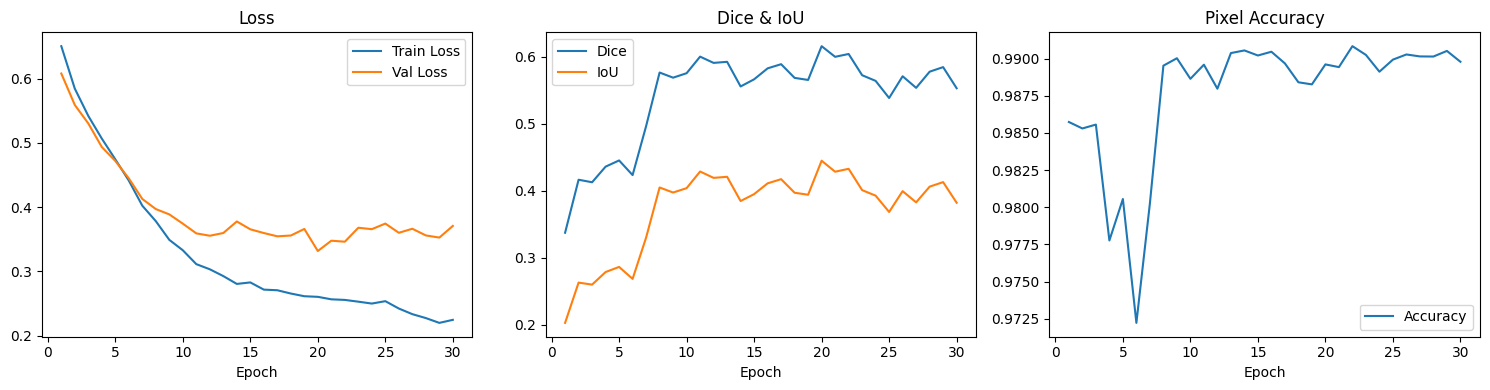

In [27]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes  = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_ran, history['val_dice'], label='Dice')
axes[1].plot(epochs_ran, history['val_iou'],  label='IoU')
axes[1].set_title('Dice & IoU'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs_ran, history['val_acc'], label='Accuracy')
axes[2].set_title('Pixel Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

## 9. Test Set Evaluation

In [28]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

test_loss = 0.0
all_preds, all_masks_list = [], []
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        test_loss += criterion(logits, masks).item() * imgs.size(0)
        all_preds.append(logits.cpu())
        all_masks_list.append(masks.cpu())
test_loss /= len(test_ds)

test_metrics = compute_metrics(torch.cat(all_preds), torch.cat(all_masks_list))

print('=' * 50)
print('Test Set Results - Attention U-Net')
print('=' * 50)
print(f'  Loss      : {test_loss:.4f}')
print(f'  Accuracy  : {test_metrics["accuracy"]:.4f}')
print(f'  Dice (F1) : {test_metrics["dice"]:.4f}')
print(f'  IoU       : {test_metrics["iou"]:.4f}')
print(f'  Hausdorff : {test_metrics["hausdorff"]:.2f}')
print('=' * 50)

Test Set Results - Attention U-Net
  Loss      : 0.3659
  Accuracy  : 0.9889
  Dice (F1) : 0.5546
  IoU       : 0.3837
  Hausdorff : 69.42


## 10. Qualitative Visualization

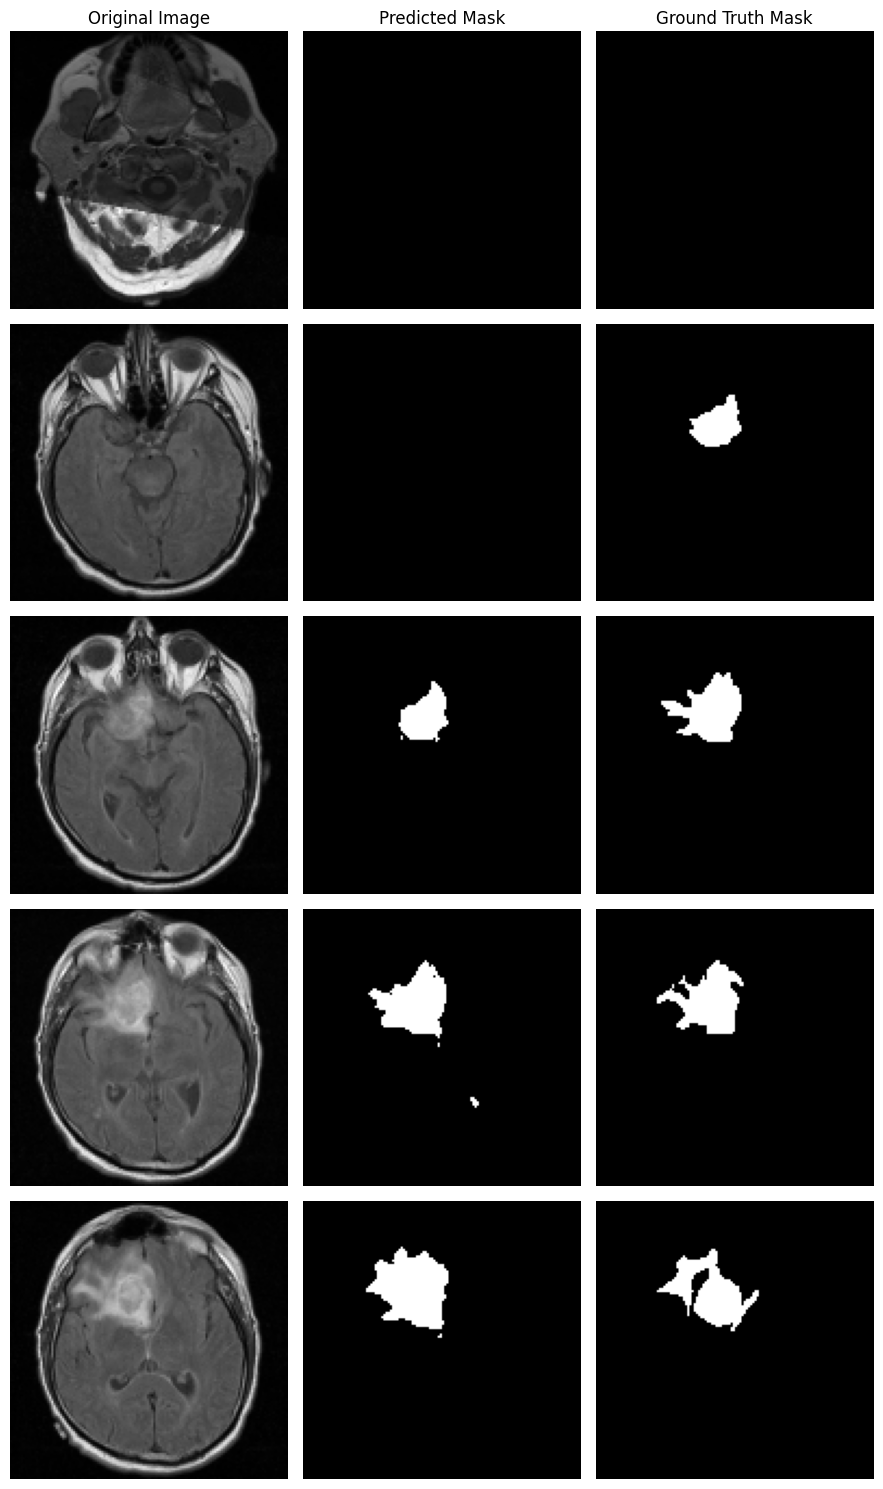

In [29]:
def show_predictions(loader, model, n=5, threshold=0.5):
    model.eval()
    imgs_shown, preds_shown, masks_shown = [], [], []
    with torch.no_grad():
        for imgs, masks in loader:
            logits = model(imgs.to(DEVICE)).cpu()
            binary = (torch.sigmoid(logits) > threshold).float()
            imgs_shown.append(imgs)
            preds_shown.append(binary)
            masks_shown.append(masks)
            if sum(len(x) for x in imgs_shown) >= n:
                break
    imgs_shown  = torch.cat(imgs_shown)[:n]
    preds_shown = torch.cat(preds_shown)[:n]
    masks_shown = torch.cat(masks_shown)[:n]

    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    for col, title in enumerate(['Original Image', 'Predicted Mask', 'Ground Truth Mask']):
        axes[0, col].set_title(title, fontsize=12)
    for i in range(n):
        axes[i, 0].imshow(imgs_shown[i, 0],  cmap='gray')
        axes[i, 1].imshow(preds_shown[i, 0], cmap='gray')
        axes[i, 2].imshow(masks_shown[i, 0], cmap='gray')
        for ax in axes[i]: ax.axis('off')
    plt.tight_layout()
    plt.savefig('/content/attention_unet_predictions.png', dpi=150)
    plt.show()


show_predictions(test_loader, model, n=5)

## 11. Save Results for Team Comparison

In [30]:
import json

results = {
    'model':     'Attention U-Net',
    'test_loss': round(test_loss, 4),
    'accuracy':  round(test_metrics['accuracy'],  4),
    'dice':      round(test_metrics['dice'],       4),
    'iou':       round(test_metrics['iou'],        4),
    'hausdorff': round(test_metrics['hausdorff'],  2),
}

with open('/content/attention_unet_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Saved to /content/attention_unet_results.json')
print(json.dumps(results, indent=2))

Saved to /content/attention_unet_results.json
{
  "model": "Attention U-Net",
  "test_loss": 0.3659,
  "accuracy": 0.9889,
  "dice": 0.5546,
  "iou": 0.3837,
  "hausdorff": 69.42
}
